# 10 - Cao et al. 2023 CNN Baseline (their architecture, our splits)

A **faithful** reproduction of the CNN that Cao et al. ship with their dataset, so the
comparison against the feature pipeline is like-for-like.

Source: `Dataset/Cao_2023/Phi-OTDR_dataset_and_codes-main/` -
`models.py` (architecture), `mydataset.py` (preprocessing), `das_data_cnn.py` (training).

## What their CNN actually is

| | their CNN | what notebook 09 ran before |
|---|---|---|
| input | full **10000 x 12** space-time record, 2D | one channel, decimated to 2048, 1D |
| scaling | per-sample **min-max to 0-255** | band-pass + z-score |
| architecture | Conv2d(1->5, 200x3, s=50x1) -> pool -> Conv2d(5->10, 20x2, s=4x1) -> pool -> Linear(400, 6) | Conv1d 64/256 + Dense(1024) |
| parameters | **7,421** | 33,152,774 |
| optimiser | Adam, lr 1e-4, weight_decay 1e-5 | Adam, lr 1e-4 |
| loss | CrossEntropy, **no class weights** | CrossEntropy with class weights |
| epochs / batch | 50 / 100 | 20 / 256 |

So the earlier baseline was not their model at all - it was ~4,500x larger and fed an
input format they never used. That comparison would not survive review.

## Two protocols, deliberately

1. **Their released 8:2 split** - reproduces the number they published.
2. **Our session-grouped split** - the same model under leakage control.

The gap between the two isolates how much of the published figure came from the fact
that 423 of 441 recording sessions appear in both their Training and Test folders.

Loading is on demand (their `MyDataset` does the same), so memory stays O(batch)
rather than holding 7 GB of records in RAM.

In [1]:
import sys, json, time
from pathlib import Path
EXPERIMENT_DIR = Path(r"/mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Experiment")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dasfe import config as C, baselines as B, evaluate as EV

sns.set_theme(style="whitegrid", context="notebook")

# ----------------------------- CONFIGURE ME -----------------------------
EPOCHS       = 50            # their das_data_cnn.py default
BATCH        = 100           # their default
LR           = 1e-4          # hardcoded in their main(), not the argparse default
WEIGHT_DECAY = 1e-5          # their default
PROTOCOLS    = ("official", "grouped")   # run both, compare
MAX_PER_CLASS = None         # None = use everything; set an int to subsample
NUM_WORKERS  = 4             # on-demand .mat loading parallelises well
# ------------------------------------------------------------------------

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev, "|", torch.cuda.get_device_name(0) if dev == "cuda" else "")

out_dir = C.results_dir("cao", "10_cnn_baseline")
mani = pd.read_parquet(C.results_dir("cao", "01_splits") / "split_manifest.parquet")
mani = mani[mani.n_bytes > 0].reset_index(drop=True)
CLASSES = sorted(mani.label.unique())
print(f"{len(mani):,} records | {len(CLASSES)} classes: {CLASSES}")
print("output:", out_dir)

device: cuda | Orin
15,418 records | 6 classes: ['background', 'dig', 'knock', 'shake', 'walk', 'water']
output: /mnt/b6bdcd1c-136a-435b-aeed-0e1b31c32749/Paper_Reeyan/Results/cao/10_cnn_baseline


## 1. Their dataset class and architecture

In [2]:
import scipy.io as scio

class CaoRecords(Dataset):
    # Mirrors their mydataset.MyDataset: load the .mat on demand, min-max to
    # 0-255, return the full 10000x12 record. No band-pass, no z-score.
    def __init__(self, frame, classes):
        self.paths = frame["path"].tolist()
        self.labels = [classes.index(v) for v in frame["label"]]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        rec = scio.loadmat(self.paths[i])["data"].astype(np.int64)
        x = B.cao_normalise(rec)                       # (10000, 12) float32, 0-255
        return torch.from_numpy(x).unsqueeze(0), self.labels[i]

net_probe = B.build_cao_cnn(len(CLASSES))
n_par = sum(p.numel() for p in net_probe.parameters())
with torch.no_grad():
    h1 = net_probe.conv1(torch.zeros(1, 1, B.CAO_TIME, B.CAO_CHANNELS))
    h2 = net_probe.conv2(h1)
print(f"architecture check: (1,{B.CAO_TIME},{B.CAO_CHANNELS}) -> {tuple(h1.shape[1:])} "
      f"-> {tuple(h2.shape[1:])} -> Linear({h2.numel()}, {len(CLASSES)})")
print(f"their stated shapes: (5, 99, 7) then (10, 10, 4)   [comments in models.py]")
print(f"parameters: {n_par:,}")

architecture check: (1,10000,12) -> (5, 99, 7) -> (10, 10, 4) -> Linear(400, 6)
their stated shapes: (5, 99, 7) then (10, 10, 4)   [comments in models.py]
parameters: 7,421


## 2. Training loop, following `das_data_cnn.py`

In [3]:
def run_protocol(frame, train_mask, test_mask, tag):
    tr_df, te_df = frame[train_mask], frame[test_mask]
    if MAX_PER_CLASS:
        tr_df = tr_df.groupby("label", group_keys=False).apply(
            lambda g: g.sample(min(len(g), MAX_PER_CLASS), random_state=C.SEED))
    print(f"\n=== {tag}: train {len(tr_df):,} | test {len(te_df):,} ===")

    tl = DataLoader(CaoRecords(tr_df, CLASSES), batch_size=BATCH, shuffle=True,
                    num_workers=NUM_WORKERS, drop_last=False)
    vl = DataLoader(CaoRecords(te_df, CLASSES), batch_size=BATCH, shuffle=False,
                    num_workers=NUM_WORKERS)

    torch.manual_seed(C.SEED)
    net = B.build_cao_cnn(len(CLASSES)).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    lossf = nn.CrossEntropyLoss()          # no class weights, as in their code

    hist, t0 = [], time.perf_counter()
    for ep in range(EPOCHS):
        net.train(); tot = 0.0; n = 0
        for xb, yb in tl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad(); l = lossf(net(xb), yb); l.backward(); opt.step()
            tot += float(l) * len(yb); n += len(yb)
        hist.append(tot / max(n, 1))
        if (ep + 1) % 10 == 0:
            print(f"  epoch {ep+1}/{EPOCHS} loss {hist[-1]:.4f}", flush=True)
    train_s = time.perf_counter() - t0

    net.eval(); preds = []
    with torch.no_grad():
        for xb, _ in vl:
            preds.append(net(xb.to(dev)).argmax(1).cpu().numpy())
    pred_i = np.concatenate(preds)
    y_true = np.array([CLASSES[i] for i in CaoRecords(te_df, CLASSES).labels])
    y_pred = np.array([CLASSES[i] for i in pred_i])

    met = EV.score_all(y_true, y_pred, labels=CLASSES)
    met.update(B.nar_fnr(y_true, y_pred, "background"))
    met.update(protocol=tag, n_train=len(tr_df), n_test=len(te_df),
               train_seconds=round(train_s, 1), n_params=n_par,
               epochs=EPOCHS, final_loss=round(hist[-1], 4))
    print(f"  accuracy {100*met['accuracy']:.2f}%  macro-F1 {100*met['f1_macro']:.2f}%  "
          f"NAR {met['NAR']:.4f}  FNR {met['FNR']:.4f}  ({train_s:.0f}s)")
    return met, y_true, y_pred, hist

In [4]:
results, curves, confusions = [], {}, {}

if "official" in PROTOCOLS:
    m, yt, yp, h = run_protocol(mani,
                               mani.official_split == "train",
                               mani.official_split == "test",
                               "Cao released 8:2 split (leaky)")
    results.append(m); curves["official"] = h
    confusions["official"] = EV.confusion(yt, yp, labels=CLASSES, normalize="true")

if "grouped" in PROTOCOLS:
    m, yt, yp, h = run_protocol(mani,
                               mani.split == "train",
                               mani.split == "test",
                               "session-grouped split (ours)")
    results.append(m); curves["grouped"] = h
    confusions["grouped"] = EV.confusion(yt, yp, labels=CLASSES, normalize="true")
    per_class = EV.per_class_report(yt, yp, labels=CLASSES)

res = pd.DataFrame(results)
display(res[["protocol", "n_train", "n_test", "accuracy", "balanced_accuracy",
             "f1_macro", "NAR", "FNR", "train_seconds"]].round(4))
res.to_csv(out_dir / "cao_cnn_results.csv", index=False)


=== Cao released 8:2 split (leaky): train 12,335 | test 3,083 ===


/tmp/ipykernel_19438/3141481164.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  tot += float(l) * len(yb); n += len(yb)


  epoch 10/50 loss 0.5182
  epoch 20/50 loss 0.3371
  epoch 30/50 loss 0.2432
  epoch 40/50 loss 0.1841
  epoch 50/50 loss 0.1464
  accuracy 92.70%  macro-F1 92.47%  NAR 0.0040  FNR 0.0100  (609s)

=== session-grouped split (ours): train 12,155 | test 1,803 ===
  epoch 10/50 loss 0.4609
  epoch 20/50 loss 0.2753
  epoch 30/50 loss 0.2197
  epoch 40/50 loss 0.1852
  epoch 50/50 loss 0.1495
  accuracy 91.13%  macro-F1 90.88%  NAR 0.0045  FNR 0.0089  (600s)


,protocol,n_train,n_test,accuracy,balanced_accuracy,f1_macro,NAR,FNR,train_seconds
0,Cao released 8:2 split (leaky),12335,3083,0.9270,0.9245,0.9247,0.0040,0.0100,609.5
1,session-grouped split (ours),12155,1803,0.9113,0.9113,0.9088,0.0045,0.0089,600.2


## 3. How much of their published number was leakage?

In [5]:
if len(res) == 2:
    off = res[res.protocol.str.contains("released")].iloc[0]
    grp = res[res.protocol.str.contains("grouped")].iloc[0]
    delta = pd.DataFrame([{
        "metric": k,
        "released 8:2 (%)": round(100*off[k], 2),
        "session-grouped (%)": round(100*grp[k], 2),
        "drop (pp)": round(100*(off[k] - grp[k]), 2),
    } for k in ("accuracy", "balanced_accuracy", "f1_macro")])
    display(delta)
    delta.to_csv(out_dir / "leakage_effect_on_cnn.csv", index=False)
    print("Any positive drop is attributable to the 423/441 recording sessions that")
    print("straddle their Training and Test folders - the model had already seen the")
    print("same continuous recording it is being tested on.")

,metric,released 8:2 (%),session-grouped (%),drop (pp)
0,accuracy,92.70,91.13,1.58
1,balanced_accuracy,92.45,91.13,1.33
2,f1_macro,92.47,90.88,1.59


Any positive drop is attributable to the 423/441 recording sessions that
straddle their Training and Test folders - the model had already seen the
same continuous recording it is being tested on.


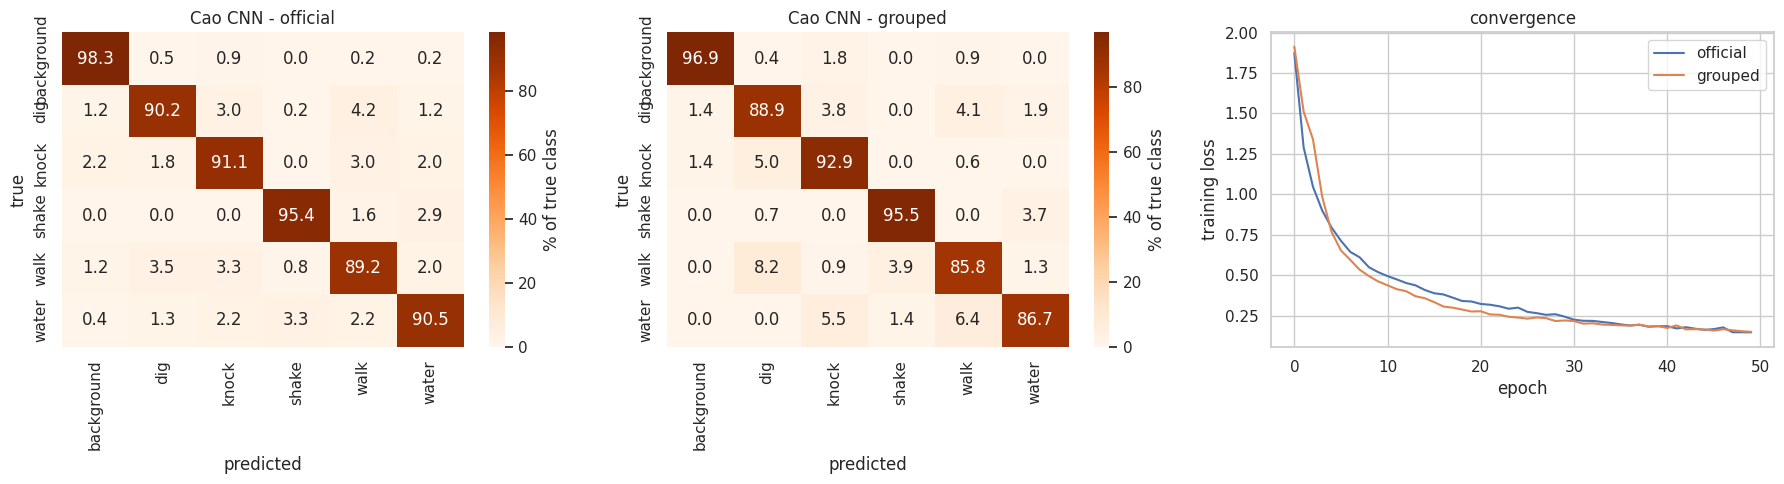

,class,precision,recall,f1-score,support
0,background,0.940,0.969,0.954,227.000
1,dig,0.864,0.889,0.876,370.000
2,knock,0.948,0.929,0.938,622.000
3,shake,0.914,0.955,0.934,134.000
4,walk,0.850,0.858,0.854,232.000
5,water,0.926,0.867,0.896,218.000
6,accuracy,0.911,0.911,0.911,0.911
7,macro avg,0.907,0.911,0.909,1803.000
8,weighted avg,0.912,0.911,0.911,1803.000


In [6]:
fig, axes = plt.subplots(1, len(confusions) + 1, figsize=(6*len(confusions) + 6, 5))
axes = np.atleast_1d(axes)
for ax, (tag, cm) in zip(axes, confusions.items()):
    sns.heatmap(100*cm, annot=True, fmt=".1f", cmap="Oranges", ax=ax,
                cbar_kws={"label": "% of true class"})
    ax.set_title(f"Cao CNN - {tag}"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
for tag, h in curves.items():
    axes[-1].plot(h, label=tag)
axes[-1].set_xlabel("epoch"); axes[-1].set_ylabel("training loss")
axes[-1].set_title("convergence"); axes[-1].legend()
plt.tight_layout()
plt.savefig(out_dir / "cao_cnn_confusion_and_loss.png", dpi=200)
plt.show()

if "grouped" in PROTOCOLS:
    display(per_class.round(3))
    per_class.to_csv(out_dir / "cao_cnn_per_class.csv", index=False)
    for tag, cm in confusions.items():
        cm.to_csv(out_dir / f"cao_cnn_confusion_{tag.split()[0]}.csv")

## 4. Head-to-head with the feature pipeline

Same dataset, same leakage-safe split, same test rows.

In [7]:
rows = []
for variant in ("full_1002", "8_consensus"):
    p = C.results_dir("cao", "07_final") / variant / "model_card.json"
    if p.exists():
        card = json.loads(p.read_text())
        rows.append({"approach": f"Multi-domain features ({variant})",
                     "model": card["model"], "n_params_or_features": card["n_features"],
                     "accuracy": card["test"]["accuracy"],
                     "balanced_accuracy": card["test"]["balanced_accuracy"],
                     "f1_macro": card["test"]["f1_macro"],
                     "inference_ms": card["inference_ms_per_sample"]})
if "grouped" in PROTOCOLS:
    g = res[res.protocol.str.contains("grouped")].iloc[0]
    rows.append({"approach": "Cao et al. 2023 CNN (their architecture)",
                 "model": "2D CNN", "n_params_or_features": int(g.n_params),
                 "accuracy": 100*g.accuracy, "balanced_accuracy": 100*g.balanced_accuracy,
                 "f1_macro": 100*g.f1_macro, "inference_ms": np.nan})

head = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(head.round(3))
head.to_csv(out_dir / "cao_head_to_head.csv", index=False)
print("\nNote: n_params_or_features is engineered features for the pipeline and")
print("trainable parameters for the CNN - they are not directly comparable, but both")
print("bound the model's capacity and its deployment cost.")

,approach,model,n_params_or_features,accuracy,balanced_accuracy,f1_macro,inference_ms
0,Multi-domain features (full_1002),LightGBM,1002,99.057,98.980,98.897,0.062
1,Multi-domain features (8_consensus),LightGBM,53,94.398,93.364,93.084,0.070
2,Cao et al. 2023 CNN (their architecture),2D CNN,7421,91.126,91.126,90.884,NaN



Note: n_params_or_features is engineered features for the pipeline and
trainable parameters for the CNN - they are not directly comparable, but both
bound the model's capacity and its deployment cost.


---
**Next:** `11_tomasov_cnn_baseline.ipynb` - the same treatment for the Tomasov CNN,
including the RDFT/DWT/MFCC front end their paper requires.